<a href="https://colab.research.google.com/github/antoinewrd1/Sleep-Health-Lifestyle-Analysis-Blood-Pressure-Prediction/blob/main/Repo_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Sleep Health and Lifestyle Analysis

Author: Antoine Ward


Goal: To utilize and analyze lifestyle and sleep factors and to preduct systolic blood pressure
"""

'\nSleep Health and Lifestyle Analysis\n\nAuthor: Antoine Ward\n\n\nGoal: To utilize and analyze lifestyle and sleep factors and to preduct systolic blood pressure\n'

In [ ]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn. metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.exceptions import ConvergenceWarning
from pathlib import Path

In [ ]:
warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)

warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning
)

sns.set_theme(style="whitegrid",
              palette="deep",
              font_scale=1.1
             )

In [ ]:
# 1. LOAD DATA

# Local dataset path
filePath = Path(
    r"C:\Users\antoi\Downloads\archive (3)\Sleep_Health_and_Lifestyle_Dataset.csv"
)

# Verify file exists
if not filePath.exists():
    raise FileNotFoundError(
        f"The dataset was not found at :\n{filePath}"
    )


# Load the dataset
df = pd.read_csv(filePath)

print(f"Dataset Shape: {df.shape}")
print("\nFirst 10 Rows:")
print(df.head(10))
print("The data has loaded successfully.")



Dataset Shape: (374, 13)

First 10 Rows:
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   
5          6   Male   28     Software Engineer             5.9   
6          7   Male   29               Teacher             6.3   
7          8   Male   29                Doctor             7.8   
8          9   Male   29                Doctor             7.8   
9         10   Male   29                Doctor             7.8   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2      

In [ ]:
# 2. DATA QUALITY CHECKS

print("Column Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Column Names:
['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']

Missing Values:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Duplicate Rows:
0

Data Types:
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object

In [ ]:
# 3. FEATURE ENGINEERING

df = df.copy()

# Split 'Blood Pressure' into 'Systolic' and 'Diastolic'
if "Blood Pressure" in df.columns:
    df[["Systolic", "Diastolic"]] = (
        df["Blood Pressure"]
        .astype(str)
        .str.split("/", expand=True)
        .astype(int)
    )

    df = df.drop(columns=["Blood Pressure"])

# Data clean 'Sleep Disorder' column if a missing value exists
if "Sleep Disorder" in df.columns:
    df["Sleep Disorder"] = df["Sleep Disorder"].fillna("No Disorder")


Descriptive Statistics:
        Person ID         Age  Sleep Duration  Quality of Sleep  \
count  374.000000  374.000000      374.000000        374.000000   
mean   187.500000   42.184492        7.132086          7.312834   
std    108.108742    8.673133        0.795657          1.196956   
min      1.000000   27.000000        5.800000          4.000000   
25%     94.250000   35.250000        6.400000          6.000000   
50%    187.500000   43.000000        7.200000          7.000000   
75%    280.750000   50.000000        7.800000          8.000000   
max    374.000000   59.000000        8.500000          9.000000   

       Physical Activity Level  Stress Level  Heart Rate   Daily Steps  \
count               374.000000    374.000000  374.000000    374.000000   
mean                 59.171123      5.385027   70.165775   6816.844920   
std                  20.830804      1.774526    4.135676   1617.915679   
min                  30.000000      3.000000   65.000000   3000.000000   
2

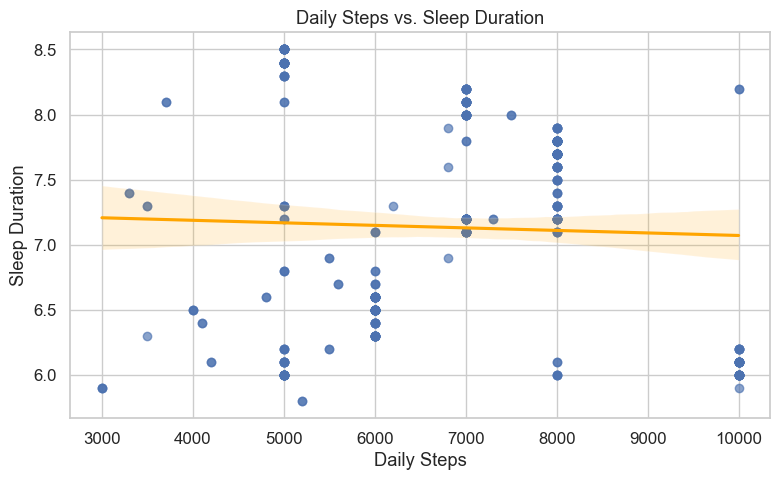

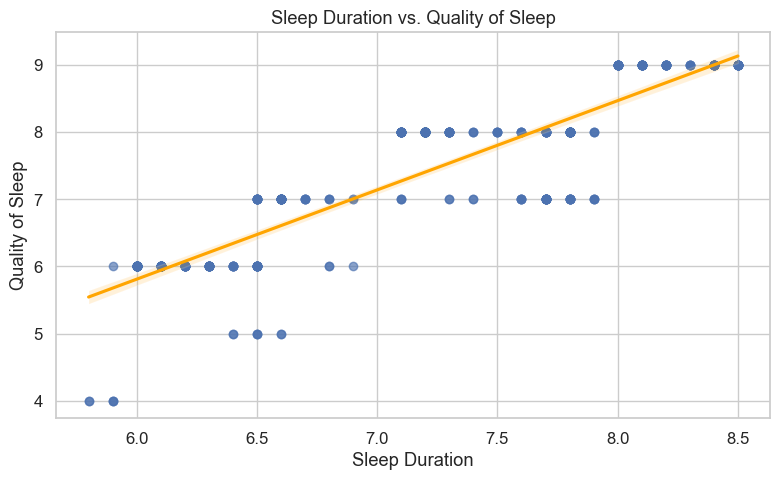

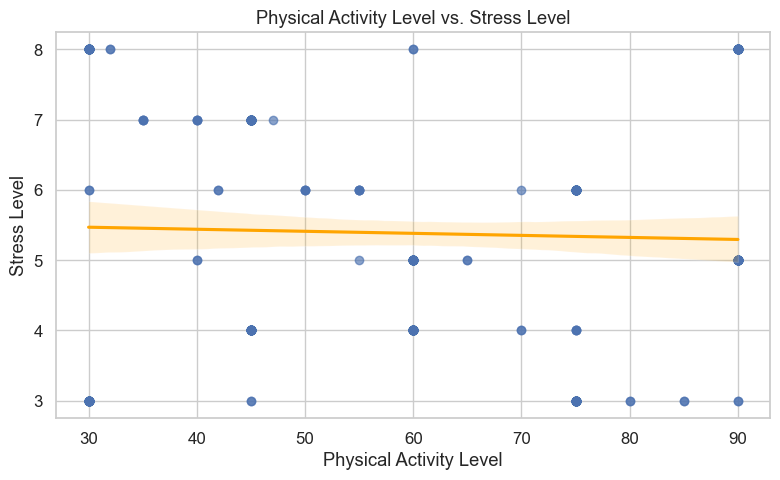

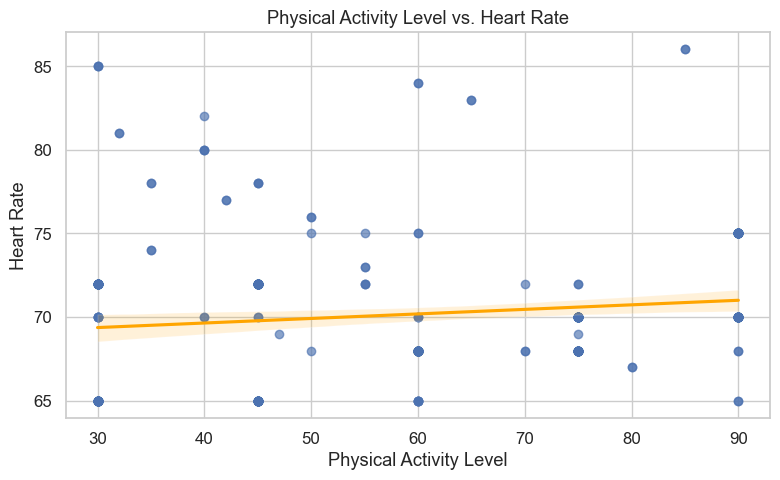

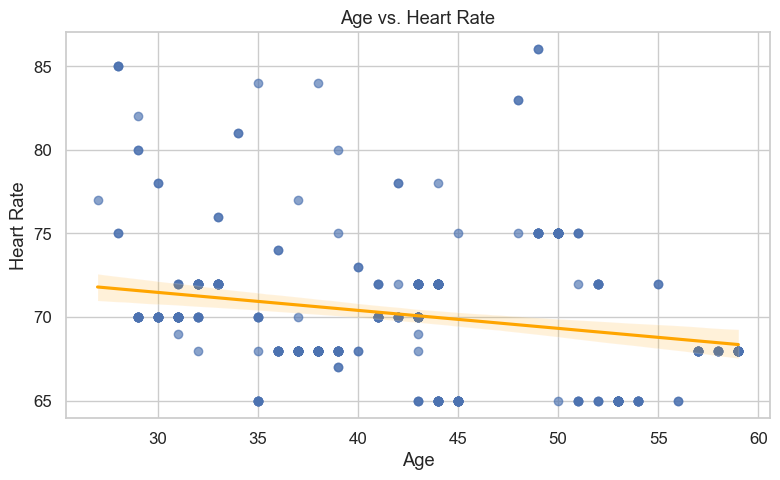

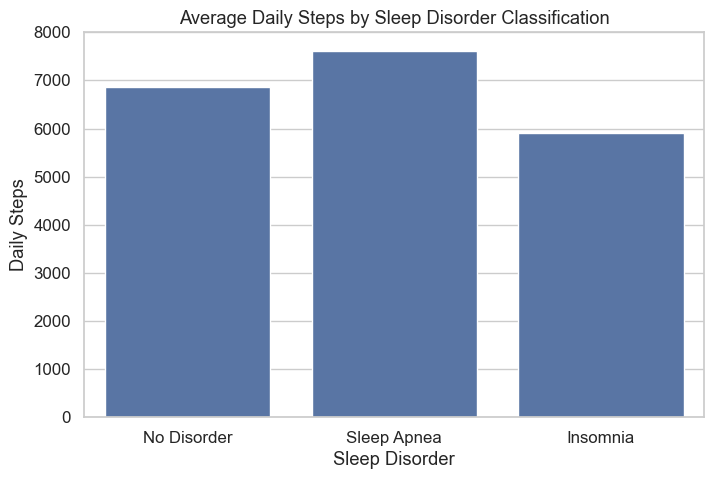

In [ ]:
# 4. EXPLORATORY DATA ANALYSIS

print("\nDescriptive Statistics:")
print(df.describe())

if "Sleep Disorder" in df.columns and "Daily Steps" in df.columns:
    average_steps = (
        df.groupby("Sleep Disorder")["Daily Steps"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    print("\nAverage Daily Steps by Sleep Disorder Classification:")
    print(average_steps)

#Regression plot function
def regression_plot(data, x, y, title):
    if x in data.columns and y in data.columns:
        plt.figure(figsize=(8,5))
        sns.regplot(
            data=data,
            x=x,
            y=y,
            scatter_kws={"alpha": 0.65},
            line_kws={"color": "orange"}
        )
        plt.title(title)
        plt.tight_layout()
        plt.show()


regression_plot(df, "Daily Steps", "Sleep Duration", "Daily Steps vs. Sleep Duration")
regression_plot(df, "Sleep Duration", "Quality of Sleep", "Sleep Duration vs. Quality of Sleep")
regression_plot(df, "Physical Activity Level", "Stress Level", "Physical Activity Level vs. Stress Level")
regression_plot(df, "Physical Activity Level", "Heart Rate", "Physical Activity Level vs. Heart Rate")
regression_plot(df, "Age", "Heart Rate", "Age vs. Heart Rate")

if "Sleep Disorder" in df.columns and "Daily Steps" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=df,
        x="Sleep Disorder",
        y="Daily Steps",
        estimator="mean",
        errorbar=None
    )
    plt.title("Average Daily Steps by Sleep Disorder Classification")
    plt.tight_layout
    plt.show()

In [ ]:
# 5. MODELING SETUP

trget = "Systolic"

if trget not in df.columns:
    raise ValueError("Target column 'Systolic' was not created successfully.")

dropColumns = ["Systolic", "Diastolic"]

X = df.drop(columns=dropColumns)
y = df[trget]

numericFeatures = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categoricalFeatures = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nnumericFeatures:")
print(numericFeatures)

print("\ncategoricalFeatures:")
print(categoricalFeatures)

numericPipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categoricalPipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numericPipeline, numericFeatures),
        ("categorical", categoricalPipeline, categoricalFeatures)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


numericFeatures:
['Person ID', 'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']

categoricalFeatures:
['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']


In [ ]:
# 6. MODEL PIPELINES

models = {
    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", RandomForestRegressor(random_state=42))
        ]
    ),

    "Gradient Boosting": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", GradientBoostingRegressor(random_state=42))
        ]
    ),

    "SVR": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", SVR())
        ]
    ),
}


In [ ]:
# 7. CROSS VALIDATION

cross_validation = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cross_validation,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "MSE": "neg_mean_squared_error",
            "R2": "r2"
        },
        return_train_score=False
    )

    cv_results.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV MSE": -scores["test_MSE"].mean(),
        "CV RMSE": np.sqrt(-scores["test_MSE"].mean()),
        "CV R2": scores["test_R2"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV RMSE")

print("\nCross-Validation Results:")
print(cv_results_df)


Cross-Validation Results:
               Model    CV MAE    CV MSE   CV RMSE     CV R2
1  Gradient Boosting  0.602705  2.456283  1.567253  0.958924
0      Random Forest  0.633748  3.263327  1.806468  0.946088
2                SVR  1.371601  6.886222  2.624161  0.884821


In [ ]:
# 8. HYPERPARAMETER TUNING

parameter_grids = {
    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2]
    },

       "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.03, 0.05, 0.10],
        "model__max_depth": [2, 3, 4],
    },

       "SVR": {
        "model__kernel": ["rbf"],
        "model__C": [1, 10, 100],
        "model__gamma": ["scale", "auto"],
        "model__epsilon": [0.1, 0.2, 0.5]
    }
}


best_models = {}

for name, model in models.items():
    print(f"\nTuning {name}...")

    grid = GridSearchCV(
        estimator=model,
        param_grid = parameter_grids[name],
        cv=cross_validation,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    print(f"Best Parameters for {name}:")
    print(grid.best_params_)
    print(f"Best CV RMSE: {-grid.best_score_:.4f}")








Tuning Random Forest...
Best Parameters for Random Forest:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV RMSE: 1.7330

Tuning Gradient Boosting...
Best Parameters for Gradient Boosting:
{'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200}
Best CV RMSE: 1.4089

Tuning SVR...
Best Parameters for SVR:
{'model__C': 100, 'model__epsilon': 0.2, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
Best CV RMSE: 1.1145


In [ ]:
# 9. FINAL TEST SET EVALUATION

test_results = []

for name, model in best_models.items():
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np. sqrt(mse)
    r2 = r2_score(y_test, predictions)

    test_results.append({
    "Model": name,
    "Test MAE": mae,
    "Test MSE": mse,
    "Test RMSE": rmse,
    "Test R2": r2
    })

test_results_df = pd.DataFrame(test_results).sort_values(by="Test RMSE")

print("\nFinal Test Results:")
print(test_results_df)


Final Test Results:
               Model  Test MAE  Test MSE  Test RMSE   Test R2
2                SVR  0.273224  0.510334   0.714377  0.990082
0      Random Forest  0.265989  0.685417   0.827899  0.986679
1  Gradient Boosting  0.305150  0.892178   0.944552  0.982660


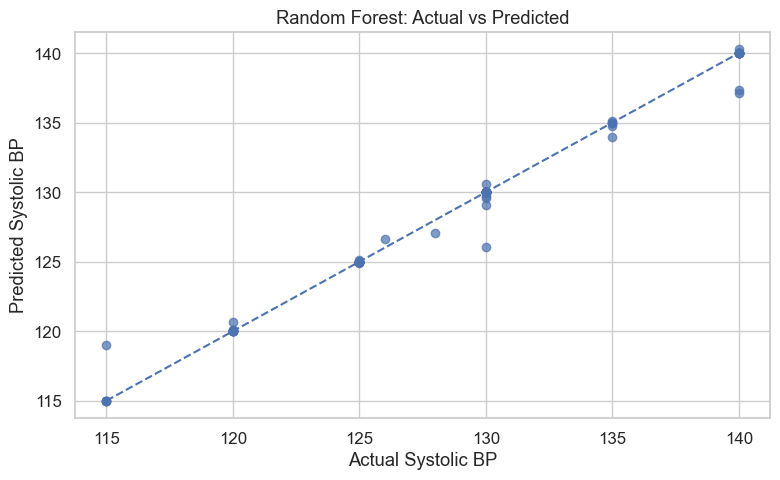

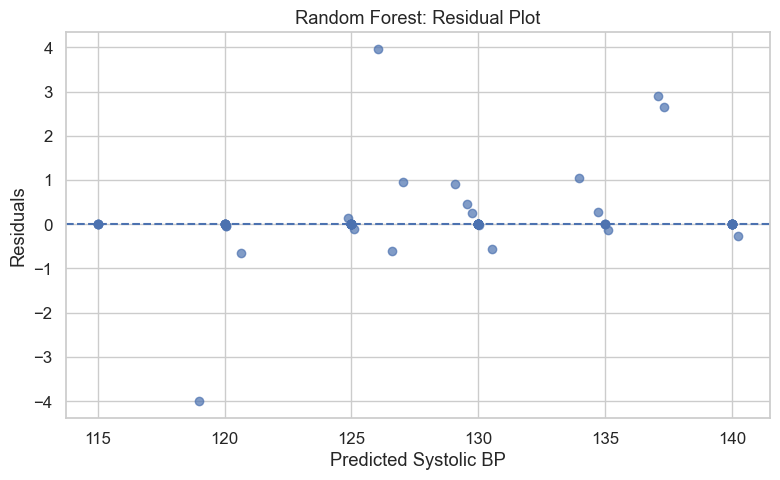

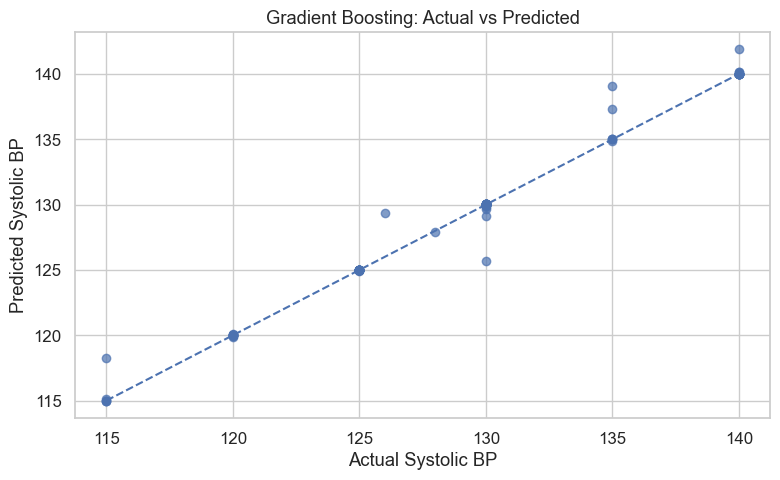

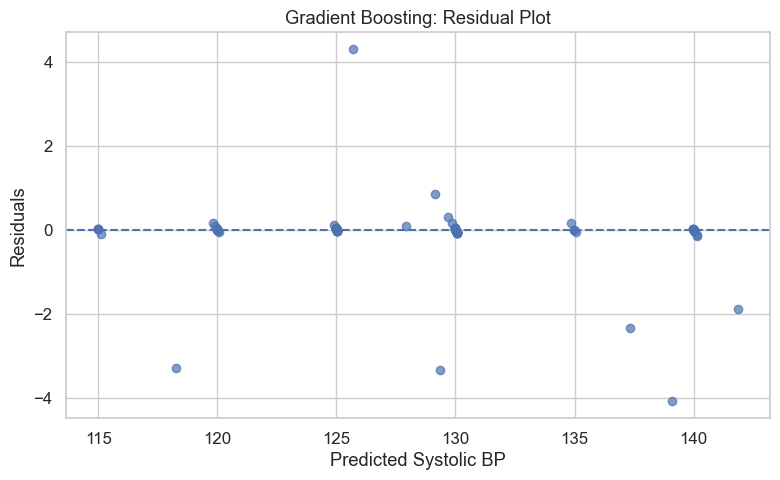

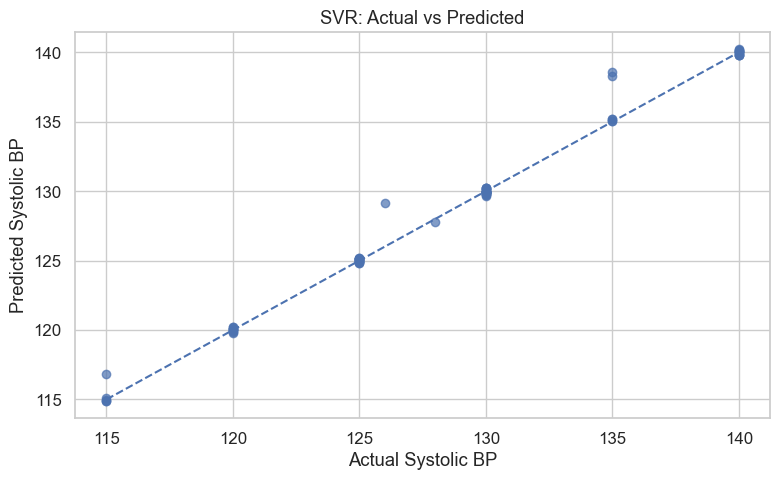

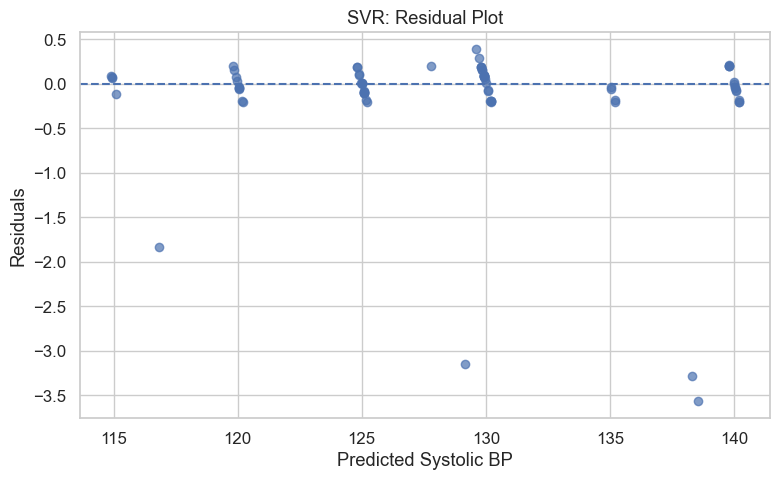

In [ ]:
# 10. PREDICTION PLOTS

def actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(8,5))
    plt.scatter(y_true, y_pred, alpha=0.70)
    plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    linestyle="--"
    )
    plt.xlabel("Actual Systolic BP")
    plt.ylabel("Predicted Systolic BP")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def residual_plot(y_true, y_pred, title):
    residuals = y_true - y_pred

    plt.figure(figsize=(8,5))
    plt.scatter(y_pred, residuals, alpha=0.70)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted Systolic BP")
    plt.ylabel("Residuals")
    plt.title(title)
    plt.tight_layout()
    plt.show()


for name, model in best_models.items():
    predictions = model.predict(X_test)

    actual_vs_predicted(
        y_test,
        predictions,
        f"{name}: Actual vs Predicted"
    )

    residual_plot(
        y_test,
        predictions,
        f"{name}: Residual Plot"
    )


Top 10 Features for Random Forest:
Sleep Disorder_No Disorder    0.241056
BMI Category_Overweight       0.230022
Person ID                     0.104245
Occupation_Accountant         0.099889
Daily Steps                   0.072589
Physical Activity Level       0.052115
Occupation_Nurse              0.046130
Age                           0.034787
Heart Rate                    0.034015
Stress Level                  0.018410
dtype: float64


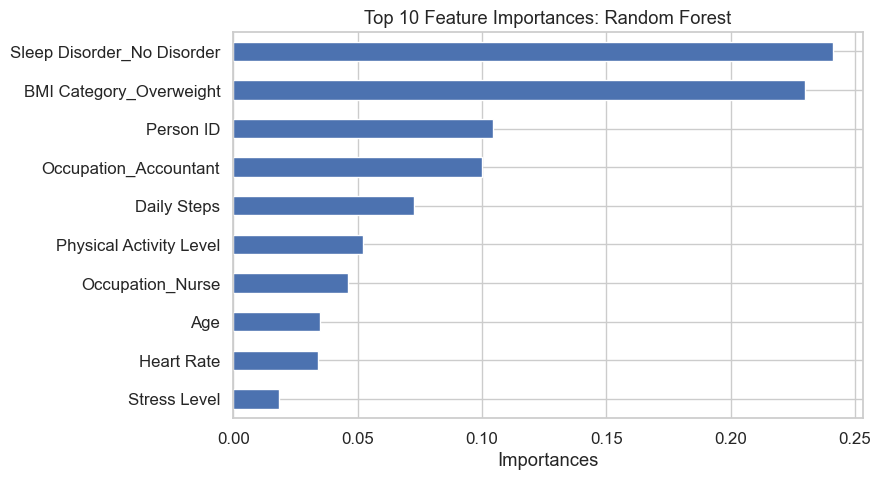


Top 10 Features for Gradient Boosting:
BMI Category_Overweight       0.350773
Sleep Disorder_No Disorder    0.133683
Occupation_Accountant         0.094641
Daily Steps                   0.084864
Person ID                     0.082175
Occupation_Nurse              0.062266
Heart Rate                    0.053535
Physical Activity Level       0.027974
Occupation_Lawyer             0.021881
Sleep Duration                0.017048
dtype: float64


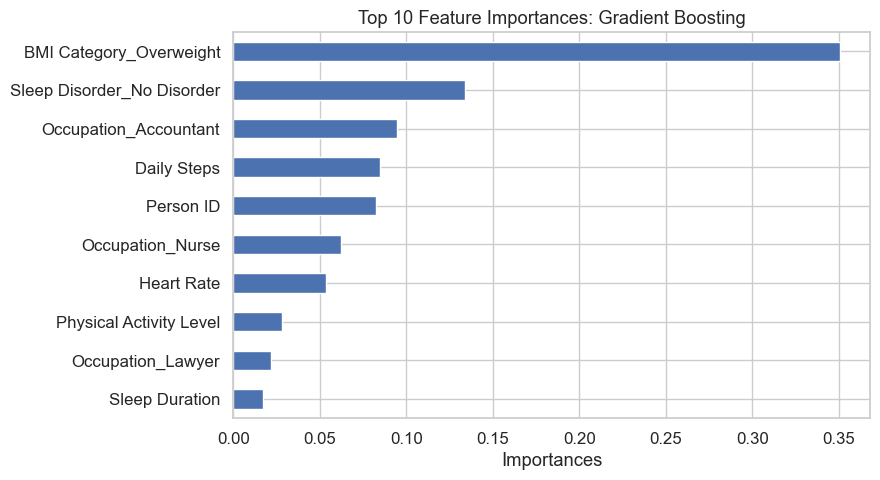

In [ ]:
# 11. FEATURE IMPORTANCE: TREE MODELS

def get_feature_names(preprocessor):

    feature_names = []

    if numericFeatures:
        feature_names.extend(numericFeatures)

    if categoricalFeatures:
        encoder = (
            preprocessor
            .named_transformers_["categorical"]
            .named_steps["encoder"]
                )

        encoded_features = encoder.get_feature_names_out(categoricalFeatures)
        feature_names.extend(encoded_features)

    return feature_names

for name in ["Random Forest", "Gradient Boosting"]:
    if name in best_models:
        model = best_models[name]
        fitted_preprocessor = model.named_steps["preprocessor"]
        fitted_estimator = model.named_steps["model"]

        feature_names = get_feature_names(fitted_preprocessor)

        importance = pd.Series(
        fitted_estimator.feature_importances_,
        index=feature_names
        ).sort_values(ascending=False)

        print(f"\nTop 10 Features for {name}:")
        print(importance.head(10))

        plt.figure(figsize=(9,5))
        importance.head(10).sort_values().plot(kind="barh")
        plt.title(f"Top 10 Feature Importances: {name}")
        plt.xlabel("Importances")
        plt.tight_layout()
        plt.show()

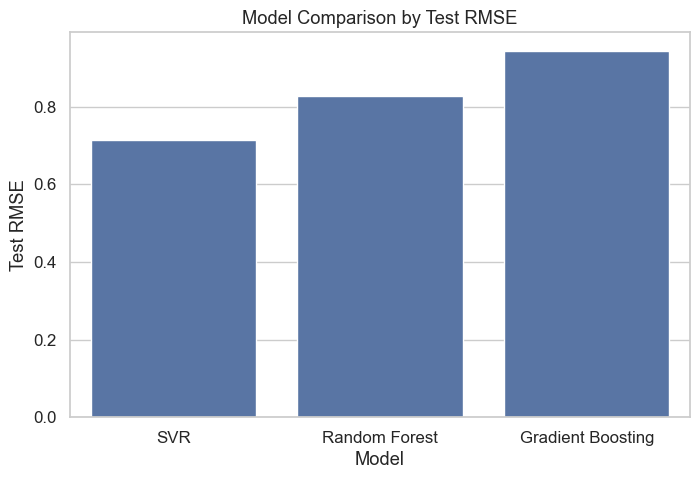

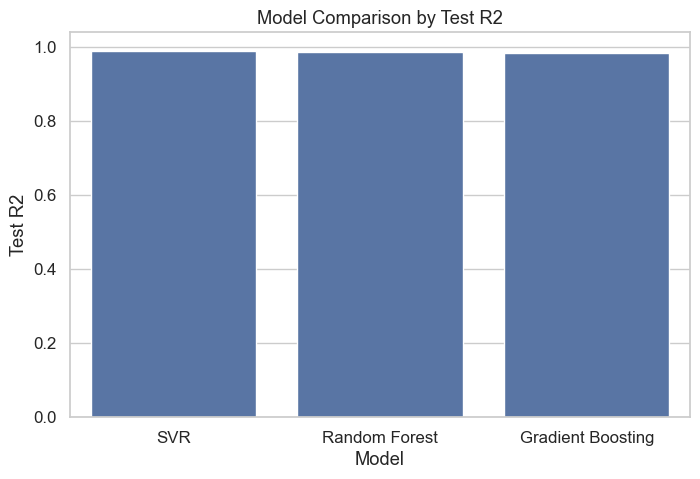

In [ ]:
# 12. MODEL COMPARISON CHARTS

plt.figure(figsize=(8, 5))
sns.barplot(data=test_results_df, x="Model", y="Test RMSE")
plt.title("Model Comparison by Test RMSE")
plt.tight_layout
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=test_results_df, x="Model", y="Test R2")
plt.title("Model Comparison by Test R2")
plt.tight_layout
plt.show()

In [ ]:
# 13. SAVE OUTPUTS

cv_results_df.to_csv("cross_validation_results.csv", index=False)
test_results_df.to_csv("test_results.csv", index = False)

print("\nSaved Files:")
print("- cross_validation_results.csv")
print("- test_results.csv")


Saved Files:
- cross_validation_results.csv
- test_results.csv
